### Uploading a file

In [2]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv
User uploaded file "retail_sales_dataset (1).csv" with length 14152545 bytes


In [4]:
df.head()
df.shape

(120000, 17)

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

,0
transaction_id,0
transaction_date,0
customer_id,0
customer_gender,0
customer_age_group,0
customer_segment,0
product_id,0
product_name,0
category,0
brand,0


In [6]:
df.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='object')

Once you upload your file, you can uncomment the line `df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))` and execute the cell again to load the data into a DataFrame. You might need to adjust `pd.read_csv` to `pd.read_excel`, `pd.read_json`, etc., depending on your file type.

In [7]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_date'].head()

,transaction_date
0,2024-04-24
1,2025-07-12
2,2025-06-01
3,2025-08-26
4,2024-12-10


In [8]:
import pandas as pd

reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (reference_date - x.max()).days,
    'transaction_id': 'count',
    'sales_amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
C000001,73,4,1401.11
C000002,33,6,1330.54
C000003,311,4,1349.69
C000004,121,4,2597.00
C000005,119,3,720.48


In [10]:
rfm.describe()

,Recency,Frequency,Monetary
count,24784.000000,24784.000000,24784.000000
mean,145.422571,4.841833,1830.094192
std,135.155948,2.159686,1127.568802
min,1.000000,1.000000,6.570000
25%,43.000000,3.000000,978.190000
50%,104.000000,5.000000,1640.400000
75%,206.000000,6.000000,2488.087500
max,730.000000,15.000000,8788.670000


In [11]:
def segment_customer(row):

    if row['Monetary'] >= 2500 and row['Frequency'] >= 6:
        return "High Value"

    elif row['Recency'] > 200:
        return "At Risk"

    else:
        return "New Customer"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Segment
customer_id,,,,
C000001,73,4,1401.11,New Customer
C000002,33,6,1330.54,New Customer
C000003,311,4,1349.69,At Risk
C000004,121,4,2597.00,New Customer
C000005,119,3,720.48,New Customer


In [12]:
segment_count = rfm['Segment'].value_counts()

print(segment_count)

Segment
New Customer    14192
At Risk          5984
High Value       4608
Name: count, dtype: int64


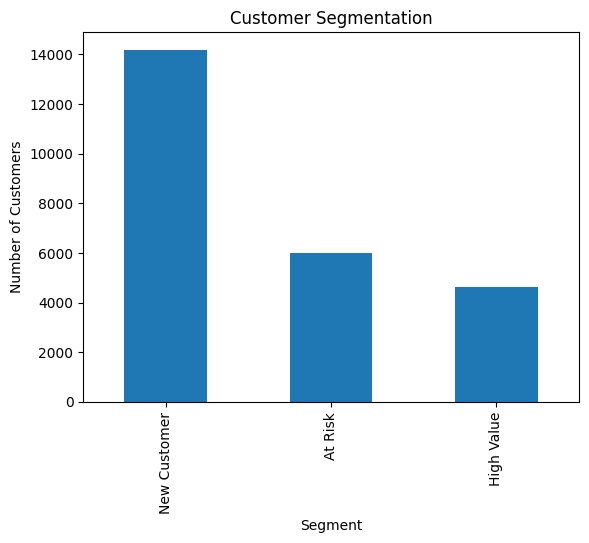

In [13]:
import matplotlib.pyplot as plt

segment_count.plot(kind='bar')

plt.title('Customer Segmentation')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

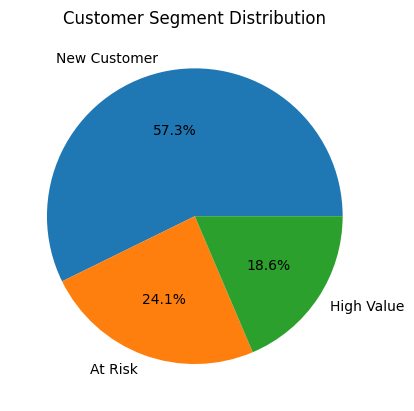

In [14]:
segment_count.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Segment Distribution')
plt.ylabel('')

plt.show()

In [15]:
rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,338.96,3.34,1209.33
High Value,87.60,7.67,3510.42
New Customer,82.59,4.55,1546.25


In [16]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum()

print(segment_revenue)

Segment
At Risk          7236657.87
High Value      16175996.93
New Customer    21944399.65
Name: Monetary, dtype: float64


In [17]:
top_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(5)

top_customers

,Recency,Frequency,Monetary,Segment
customer_id,,,,
C001502,6,13,8788.67,High Value
C013102,79,11,8401.58,High Value
C009405,283,13,7993.31,High Value
C024216,96,11,7840.01,High Value
C000351,12,14,7808.19,High Value


# Insights

1. Customer segmentation identified High Value, New Customer, and At Risk customer groups.

2. High Value customers contribute a significant portion of total revenue and should be prioritized for retention.

3. At Risk customers have not made purchases recently and may require re-engagement campaigns.

4. The top 5 customers contribute substantially to overall sales, highlighting the importance of customer loyalty.

5. Revenue distribution across customer segments helps businesses focus marketing efforts more effectively.

# Business Recommendations

1. Launch a loyalty rewards program for High Value customers to increase retention and repeat purchases.

2. Send personalized discounts, email campaigns, or special offers to At Risk customers to encourage them to return.

3. Provide welcome offers and product recommendations to New Customers to convert them into loyal customers.